# Car_price_prediction

# ==========================================================
# 1. Problem Statement
# ==========================================================

"""
The objective of this project is to build a Machine Learning
model that predicts the selling price of used cars based on
features such as car name, year, fuel type, transmission,
and kilometers driven.

This helps buyers and sellers estimate fair market prices
for used vehicles.
"""

In [939]:
#step1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [940]:
# step 2 Load dataset
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')


# ==========================================================
# 2. Data Understanding
# ==========================================================

In [941]:
df.head() # display first 5 rows

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [942]:
# step 3 total no.of rows and columns
df.shape

(4340, 8)

In [943]:
# step 4 dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


=====================================================================

#3. DATA CLEANING

=====================================================================

In [944]:
# step 5: check mising value
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [945]:
#step 7check duplicate rows and remove if any
df.duplicated().sum()

np.int64(763)

In [946]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [947]:
df.shape

(3577, 8)

In [948]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [949]:
df.drop(['seller_type'], axis = 1, inplace = True)
df.drop(['owner'], axis = 1, inplace = True)
df.head()

,name,year,selling_price,km_driven,fuel,transmission
0,Maruti 800 AC,2007,60000,70000,Petrol,Manual
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Manual
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Manual
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Manual
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Manual


In [950]:
df['name'].unique()

array(['Maruti 800 AC', 'Maruti Wagon R LXI Minor',
       'Hyundai Verna 1.6 SX', ..., 'Mahindra Verito 1.5 D6 BSIII',
       'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV',
       'Hyundai i20 Magna 1.4 CRDi'], dtype=object)

In [951]:
df['name'].value_counts()

,count
name,
Maruti Swift Dzire VDI,54
Maruti Alto 800 LXI,48
Maruti Alto LXi,42
Maruti Alto LX,30
Maruti Swift VDI BSIV,28
...,...
Tata Indica V2 DLS BSII,1
Mahindra XUV500 W10 AWD,1
Toyota Fortuner 2.7 2WD AT,1


In [952]:
df.head()

,name,year,selling_price,km_driven,fuel,transmission
0,Maruti 800 AC,2007,60000,70000,Petrol,Manual
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Manual
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Manual
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Manual
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Manual


=====================================================================

#4. EDA (Exploratory Data Analysis)

======================================================================

<Axes: xlabel='selling_price', ylabel='Count'>

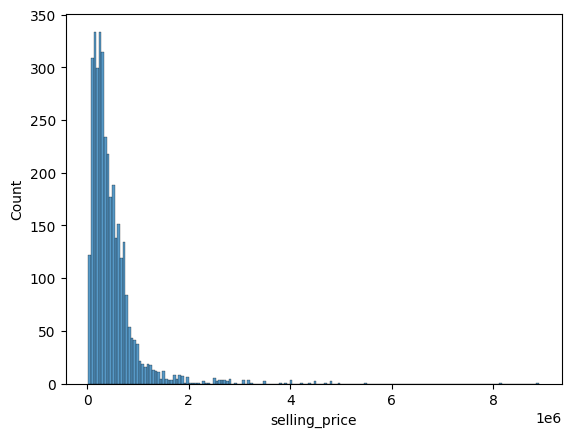

In [953]:
sns.histplot(df['selling_price'])

<Axes: ylabel='selling_price'>

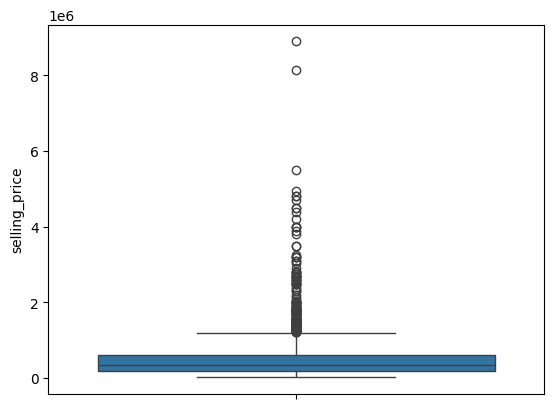

In [954]:
sns.boxplot(df['selling_price'])

<Axes: xlabel='km_driven', ylabel='selling_price'>

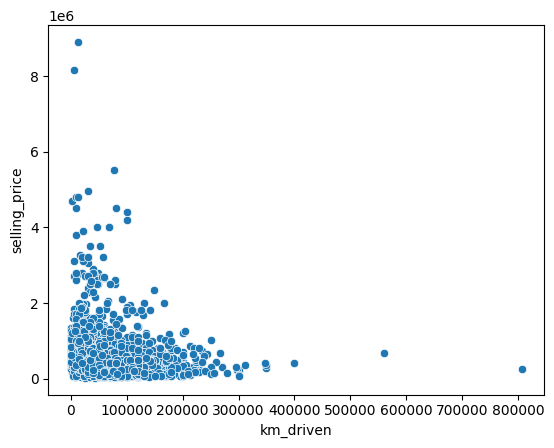

In [955]:
sns.scatterplot(x='km_driven', y='selling_price', data=df)

👆The distribution of selling prices is highly right-skewed.
Most vehicles belong to lower and medium price ranges,
while a small number of luxury vehicles create a long
right tail in the distribution.

This skewness can negatively affect regression model
performance because extreme values dominate the learning
process.

#5. FEATURE ENGINEERING

In [956]:
#step 8: Encode categorical columns
df.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
transmission,object


In [957]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.dtypes

,0
name,int64
year,int64
selling_price,int64
km_driven,int64
fuel,int64
transmission,int64


In [958]:
#df = pd.get_dummies(df, drop_first=True)

In [959]:
#bool_cols = df.select_dtypes(include ='bool').columns
#df[bool_cols] = df[bool_cols].astype(int)

In [960]:
df.dtypes

,0
name,int64
year,int64
selling_price,int64
km_driven,int64
fuel,int64
transmission,int64


In [961]:
#df['car_age'] = 2026 - df['year']

#df['km_per_year'] = df['km_driven'] / df['car_age']
df['selling_price'] = np.log1p(df['selling_price'])

In [962]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'transmission'], dtype='object')

◀Log transformation was applied to reduce skewness
and stabilize variance in the target variable.

#6. MODEL TRAINING

In [963]:
# select features and target
X = df.drop('selling_price', axis = 1)
y = df['selling_price']
X

,name,year,km_driven,fuel,transmission
0,775,2007,70000,4,1
1,1041,2007,50000,4,1
2,505,2012,100000,1,1
3,118,2017,46000,4,1
4,279,2014,141000,1,1
...,...,...,...,...,...
4335,602,2014,80000,1,1
4336,601,2014,80000,1,1
4337,777,2009,83000,4,1
4338,381,2016,90000,1,1


In [964]:
df.shape

(3577, 6)

In [965]:
df.describe()

,name,year,selling_price,km_driven,fuel,transmission
count,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000
mean,756.502376,2012.962538,12.730345,69250.545709,2.442270,0.912776
std,397.128886,4.251759,0.817206,47579.940016,1.508582,0.282202
min,0.000000,1992.000000,9.903538,1.000000,0.000000,0.000000
25%,435.000000,2010.000000,12.206078,36000.000000,1.000000,1.000000
50%,793.000000,2013.000000,12.765691,60000.000000,1.000000,1.000000
75%,1048.000000,2016.000000,13.304687,90000.000000,4.000000,1.000000
max,1490.000000,2020.000000,16.001562,806599.000000,4.000000,1.000000


In [966]:
#step 10 split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

In [967]:
# Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [968]:
#step 11 create the model
model = LinearRegression()


In [969]:
#step 12 train the model
model.fit(X_train, y_train)

LinearRegression()

In [970]:
#step13 predict the output
y_pred = model.predict(X_test)

In [971]:
# Convert back to original price scale
real_predictions = np.expm1(y_pred)
real_y_test = np.expm1(y_test)

#7 Model Evaluation - Linear Regression

In [972]:
#step14 model Evaluation
r2_score(y_test, y_pred)

0.6647499644194474

In [973]:
mean_absolute_error(y_test, y_pred)

0.3690313152421964

In [974]:
mean_squared_error(y_test, y_pred)

0.2298860695626037

In [975]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(0.47946435692614703)

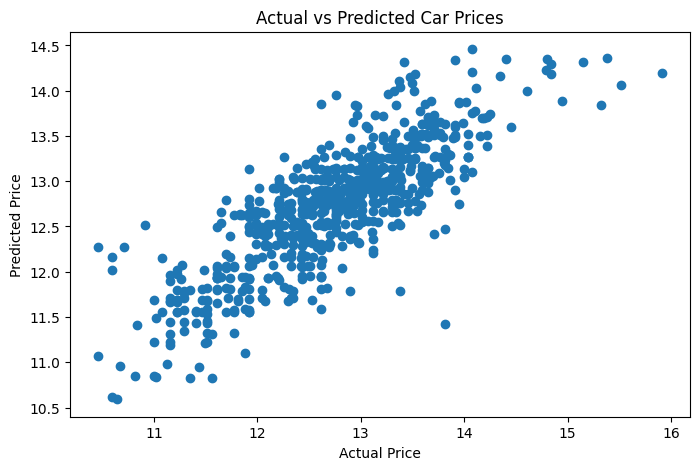

In [976]:
# Step 16: Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

#Decision Tree Regression Model

In [977]:
from sklearn.tree import DecisionTreeRegressor


In [978]:
dt_model = DecisionTreeRegressor()

In [979]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [980]:
y_pred = dt_model.predict(X_test)

In [981]:
# Convert back to original price scale
real_predictions = np.expm1(y_pred)

real_y_test = np.expm1(y_test)

### Model Evaluation

In [982]:
r2_score(y_test, y_pred)

0.7202016847627519

In [983]:
mean_squared_error(y_test, y_pred)

0.1918619780270667

In [984]:
mean_absolute_error(y_test, y_pred)

0.31171965558267045

In [985]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(0.43802052238116274)

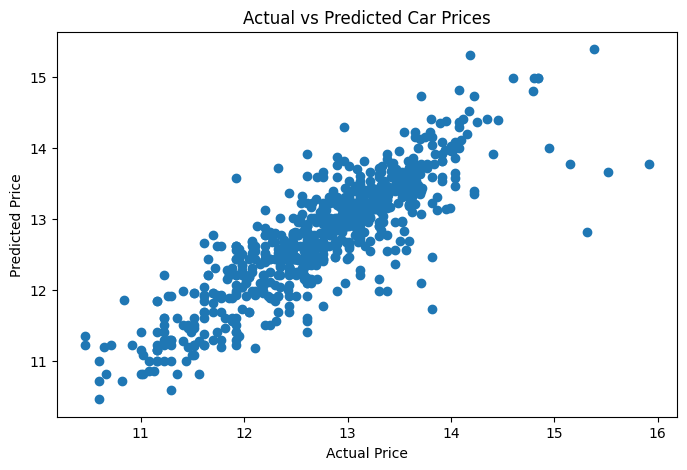

In [986]:
# Step 16: Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

#Random Forest Regression Algorithm(With hyper parameter tuning)

In [987]:
from sklearn.ensemble import RandomForestRegressor

In [988]:
rf_model = RandomForestRegressor(
       n_estimators=350,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [989]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=25, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=350, random_state=42)

In [990]:
y_pred = rf_model.predict(X_test)

In [991]:
# Convert back to original price scale
real_predictions = np.expm1(y_pred)

real_y_test = np.expm1(y_test)

In [992]:
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(np.sqrt(mean_squared_error(y_test, y_pred)))

0.8142277083671552
0.12738689761257643
0.2537160039198652
0.3569130112682591


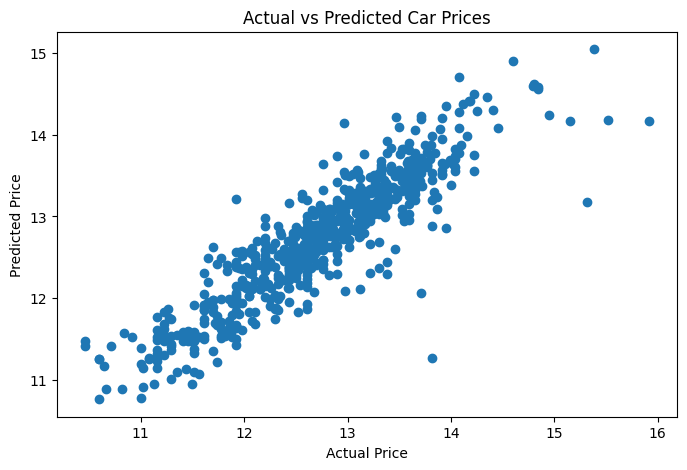

In [993]:
# Step 16: Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [994]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

        Feature  Importance
1          year    0.525102
0          name    0.224114
4  transmission    0.101426
3          fuel    0.095198
2     km_driven    0.054159


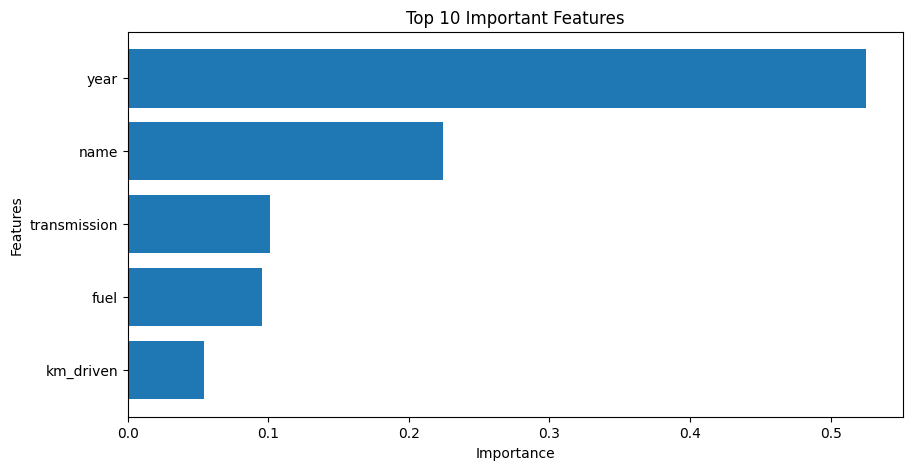

In [995]:
import matplotlib.pyplot as plt

top_features = importance.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [996]:
comparison = pd.DataFrame({
    'Actual Price': real_y_test,
    'Predicted Price': real_predictions
})

print(comparison.head(10))

      Actual Price  Predicted Price
1045      270000.0     3.898469e+05
3194      525000.0     4.580761e+05
1530      990000.0     1.065231e+06
553      3800000.0     1.434604e+06
1612      229999.0     1.675629e+05
2652      325000.0     2.868300e+05
152       210000.0     1.479737e+05
3985      500000.0     6.197424e+05
1059      790000.0     8.751230e+05
3788      360000.0     3.730814e+05


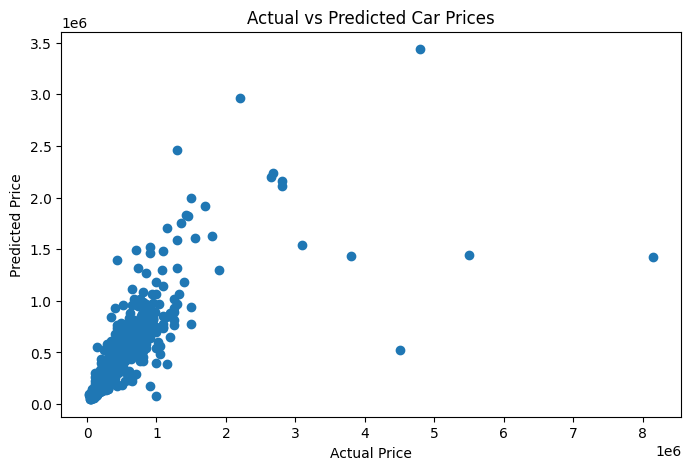

In [997]:
plt.figure(figsize=(8,5))

plt.scatter(real_y_test, real_predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

#XGBOOST ALGORITHM

In [998]:
! pip install xgboost

In [999]:
from xgboost import XGBRegressor

In [1000]:
xg_model = XGBRegressor()
xg_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [1001]:
y_pred = xg_model.predict(X_test)

In [1002]:
r2_score(y_test, y_pred)   #with log transformation

0.8328217063457366

In [1003]:
mean_squared_error(y_test, y_pred)

0.11463670921856497

In [1004]:
mean_absolute_error(y_test, y_pred)

0.23998939512690248

In [1005]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(0.3385804324212564)

In [1006]:
real_predictions = np.expm1(y_pred)

real_y_test = np.expm1(y_test)

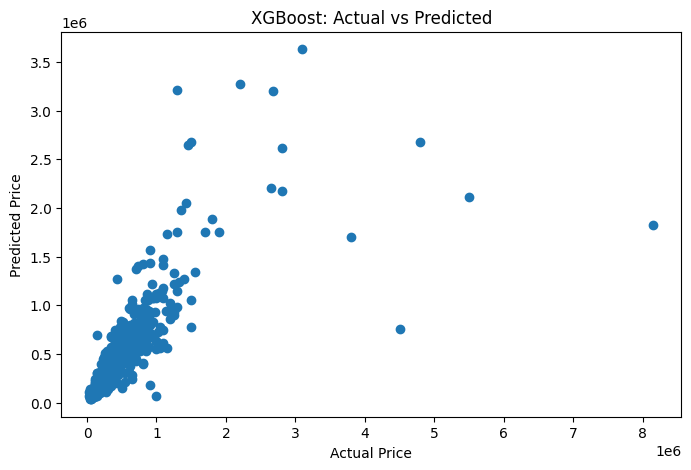

In [1007]:
plt.figure(figsize=(8,5))

plt.scatter(real_y_test, real_predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("XGBoost: Actual vs Predicted")

plt.show()

#8. MODEL COMPARISON:

# Model Comparison Table

| Algorithm               | R² Score | MSE   | MAE   | RMSE  | Performance Analysis                                                                                                                                 |
| ----------------------- | -------- | ----- | ----- | ----- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| Linear Regression       | 0.66     | 0.230 | 0.369 | 0.479 | Linear Regression achieved moderate performance after log transformation but struggled to capture complex non-linear relationships in the dataset.   |
| Decision Tree Regressor | 0.72     | 0.192 | 0.312 | 0.438 | Decision Tree performed better than Linear Regression but showed moderate variance and possible overfitting tendencies.                              |
| Random Forest Regressor | 0.81     | 0.127 | 0.254 | 0.357 | Random Forest achieved strong performance due to ensemble learning and improved generalization capability.                                           |
| XGBoost Regressor       | 0.84     | 0.115 | 0.240 | 0.339 | XGBoost achieved the best overall performance by sequentially correcting prediction errors and effectively learning complex patterns in the dataset. |

# Key Findings

* The selling price feature showed heavy right skewness and multiple outliers.
* Applying log transformation significantly improved the performance of all regression models.
* Ensemble learning models outperformed traditional Linear Regression.
* Random Forest and XGBoost handled non-linear relationships more effectively.
* XGBoost with log-transformed target variable produced the best overall performance with an R² score of approximately 0.84.

# Final Selected Model

## XGBoost Regressor with Log Transformation

### Final Performance:

* R² Score: 0.84
* RMSE: 0.339
* MAE: 0.240

The final model successfully predicts used car selling prices with strong regression performance and improved generalization capability.


#9 Final model:

  ### Final selected model:
  XGBoost Regressor with log-transformed target variable.

#10. RESULTS:

R² Score = 0.84

#11. CONCLUSION:

This project successfully developed a car price prediction
model using Machine Learning techniques.

Among all tested algorithms, XGBoost with log-transformed
target values achieved the best performance with an
R² score of approximately 0.84.

The project demonstrated the importance of preprocessing,
target transformation, ensemble learning, and model tuning
in improving regression performance.

In [1008]:
df.to_csv('car_price.csv', index=False)